<a href="https://colab.research.google.com/github/xiaoyuguo-del/TFM_Seguridad_Vial_Madrid/blob/main/05_Sensibilidad_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
=== ANÁLISIS DE SENSIBILIDAD — SCORE FINAL ===
Referencia: 60% IPD / 40% IRP

Escenario                  Rho vs base   Top5 estable
-------------------------------------------------------
100% IPD / 0% IRP               0.9221         ⚠️ 4/5
80% IPD / 20% IRP               0.9623         ⚠️ 4/5
70% IPD / 30% IRP               0.9883         ⚠️ 4/5
60% IPD / 40% IRP               1.0000           ✅ Sí ← BASE
50% IPD / 50% IRP               0.9922           ✅ Sí
40% IPD / 60% IRP               0.9571           ✅ Sí
20% IPD / 80% IRP               0.8636         ⚠️ 4/5
0% IPD / 100% IRP               0.7247         ⚠️ 3/5

Rho mínimo (escenarios no extremos): 0.8636
Todos los escenarios rho ≥ 0.90: ⚠️ No

=== RANKING TOP 10 POR ESCENARIO ===
          distrito  rank_100% IPD / 0% IRP  rank_80% IPD / 20% IRP  rank_70% IPD / 30% IRP  rank_60% IPD / 40% IRP  rank_50% IPD / 50% IRP  rank_40% IPD / 60% IRP  rank_20% IPD / 80% IRP  rank_0% IPD / 100% IRP
            CE

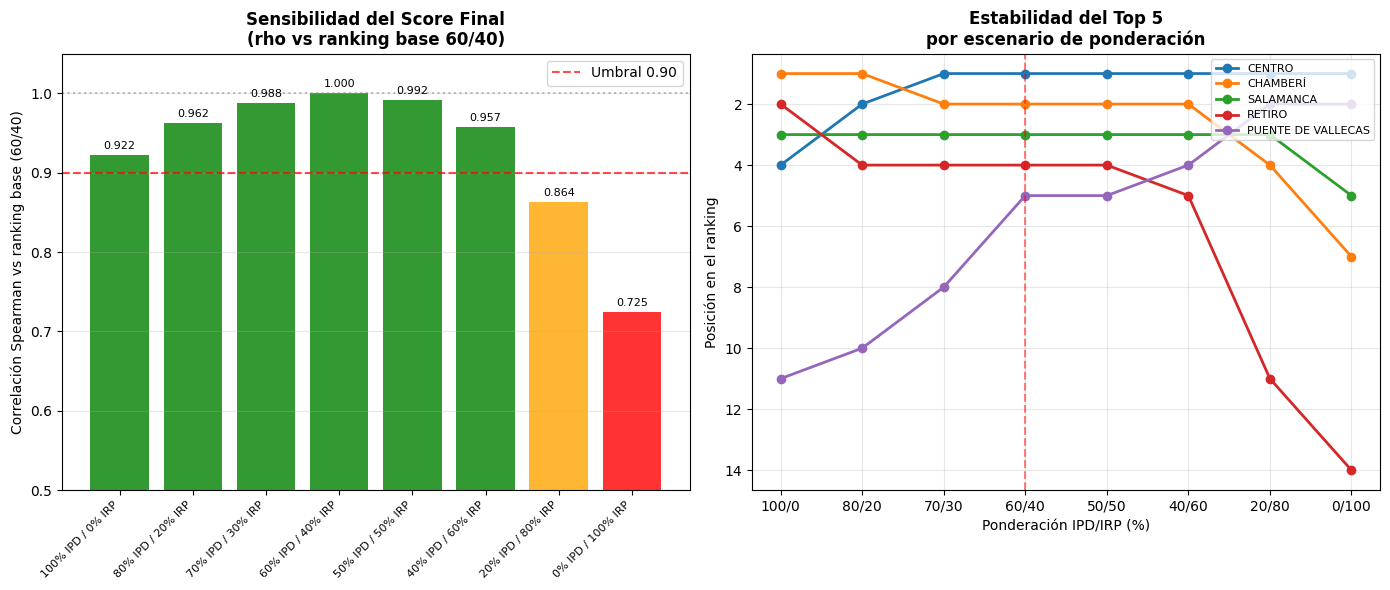

✅ sensibilidad_score_final.png guardada
✅ sensibilidad_score_final.csv guardada


In [ ]:
# ══════════════════════════════════════════════════════════
# ANÁLISIS DE SENSIBILIDAD — Score Final IPD/IRP
# Objetivo: demostrar que el ranking es robusto ante
# distintas ponderaciones IPD/IRP
# ══════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE    = '/content/drive/MyDrive/TFM_Seguridad_Vial'
outputs = f'{BASE}/outputs'

# Cargamos IPD e IRP
ipd = pd.read_csv(f'{outputs}/IPD_ranking_medio.csv')
ipd.columns = ['posicion', 'distrito', 'IPD_medio']
mn_ipd = ipd['IPD_medio'].min()
mx_ipd = ipd['IPD_medio'].max()
ipd['IPD_norm'] = ((ipd['IPD_medio'] - mn_ipd) / (mx_ipd - mn_ipd) * 100).round(2)

irp = pd.read_csv(f'{outputs}/IRP_prediccion_2025.csv')
irp.columns = ['posicion', 'distrito', 'acc_pred_2025', 'IRP']

df = ipd[['distrito', 'IPD_norm']].merge(irp[['distrito', 'IRP']], on='distrito')

# ── Escenarios de ponderación ─────────────────────────────
escenarios = [
    {'nombre': '100% IPD / 0% IRP',  'w_ipd': 1.00, 'w_irp': 0.00},
    {'nombre':  '80% IPD / 20% IRP', 'w_ipd': 0.80, 'w_irp': 0.20},
    {'nombre':  '70% IPD / 30% IRP', 'w_ipd': 0.70, 'w_irp': 0.30},
    {'nombre':  '60% IPD / 40% IRP', 'w_ipd': 0.60, 'w_irp': 0.40},  # base
    {'nombre':  '50% IPD / 50% IRP', 'w_ipd': 0.50, 'w_irp': 0.50},
    {'nombre':  '40% IPD / 60% IRP', 'w_ipd': 0.40, 'w_irp': 0.60},
    {'nombre':  '20% IPD / 80% IRP', 'w_ipd': 0.20, 'w_irp': 0.80},
    {'nombre':   '0% IPD / 100% IRP', 'w_ipd': 0.00, 'w_irp': 1.00},
]

# Score base (60/40)
df['score_base'] = (df['IPD_norm'] * 0.60 + df['IRP'] * 0.40).round(2)
df['rank_base']  = df['score_base'].rank(ascending=False).astype(int)

# ── Cálculo de rho para cada escenario ───────────────────
print('=== ANÁLISIS DE SENSIBILIDAD — SCORE FINAL ===')
print(f'Referencia: 60% IPD / 40% IRP\n')
print(f'{"Escenario":<25} {"Rho vs base":>12} {"Top5 estable":>14}')
print('-' * 55)

resultados_sens = []

for esc in escenarios:
    df[f'score_{esc["nombre"]}'] = (
        df['IPD_norm'] * esc['w_ipd'] +
        df['IRP']      * esc['w_irp']
    ).round(2)
    df[f'rank_{esc["nombre"]}'] = df[f'score_{esc["nombre"]}'].rank(ascending=False).astype(int)

    rho, p = spearmanr(df['rank_base'], df[f'rank_{esc["nombre"]}'])

    # Top 5 estable: los 5 primeros del ranking base siguen en top 5
    top5_base = set(df[df['rank_base'] <= 5]['distrito'])
    top5_esc  = set(df[df[f'rank_{esc["nombre"]}'] <= 5]['distrito'])
    top5_ok   = '✅ Sí' if top5_base == top5_esc else f'⚠️ {len(top5_base & top5_esc)}/5'

    marca = ' ← BASE' if esc['w_ipd'] == 0.60 else ''
    print(f'{esc["nombre"]:<25} {rho:>12.4f} {top5_ok:>14}{marca}')

    resultados_sens.append({
        'escenario':  esc['nombre'],
        'w_ipd':      esc['w_ipd'],
        'w_irp':      esc['w_irp'],
        'rho_vs_base': round(rho, 4),
        'top5_estable': top5_base == top5_esc
    })

df_sens = pd.DataFrame(resultados_sens)

# Resumen
rho_min = df_sens[df_sens['w_ipd'] > 0]['rho_vs_base'].min()
todos_ok = (df_sens['rho_vs_base'] >= 0.90).all()
print(f'\nRho mínimo (escenarios no extremos): {rho_min:.4f}')
print(f'Todos los escenarios rho ≥ 0.90: {"✅ Sí" if todos_ok else "⚠️ No"}')

# ── Ranking por escenario — Top 10 ────────────────────────
print('\n=== RANKING TOP 10 POR ESCENARIO ===')
cols_rank = ['distrito'] + [f'rank_{e["nombre"]}' for e in escenarios]
top10 = df[df['rank_base'] <= 12].sort_values('rank_base')[cols_rank]
print(top10.to_string(index=False))

# ── Visualización ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda: rho por escenario
ax = axes[0]
pesos_ipd = [e['w_ipd'] for e in escenarios]
rhos      = df_sens['rho_vs_base'].values
colores   = ['green' if r >= 0.90 else 'orange' if r >= 0.80 else 'red' for r in rhos]
bars = ax.bar([e['nombre'] for e in escenarios], rhos, color=colores, alpha=0.8)
ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label='Umbral 0.90')
ax.axhline(y=1.00, color='gray', linestyle=':', alpha=0.5)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Correlación Spearman vs ranking base (60/40)')
ax.set_title('Sensibilidad del Score Final\n(rho vs ranking base 60/40)',
             fontweight='bold')
ax.set_xticklabels([e['nombre'] for e in escenarios], rotation=45, ha='right', fontsize=8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Añadimos el valor encima de cada barra
for bar, rho in zip(bars, rhos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{rho:.3f}', ha='center', va='bottom', fontsize=8)

# Derecha: posición de top 5 en cada escenario
ax2 = axes[1]
top5_distritos = df[df['rank_base'] <= 5].sort_values('rank_base')['distrito'].tolist()
escenario_labels = [f'{int(e["w_ipd"]*100)}/{int(e["w_irp"]*100)}' for e in escenarios]

for i, distrito in enumerate(top5_distritos):
    posiciones = [
        df[df['distrito'] == distrito][f'rank_{e["nombre"]}'].values[0]
        for e in escenarios
    ]
    ax2.plot(escenario_labels, posiciones, marker='o', linewidth=2,
             label=distrito, markersize=6)

ax2.set_xlabel('Ponderación IPD/IRP (%)')
ax2.set_ylabel('Posición en el ranking')
ax2.set_title('Estabilidad del Top 5\npor escenario de ponderación', fontweight='bold')
ax2.invert_yaxis()
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(alpha=0.3)
ax2.axvline(x='60/40', color='red', linestyle='--', alpha=0.5, label='Base')

plt.tight_layout()
plt.savefig(f'{outputs}/sensibilidad_score_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ sensibilidad_score_final.png guardada')

# Guardamos tabla de sensibilidad
df_sens.to_csv(f'{outputs}/sensibilidad_score_final.csv', index=False, encoding='utf-8-sig')
print('✅ sensibilidad_score_final.csv guardada')

In [ ]:
import pandas as pd
dfs = {name: obj for name, obj in globals().items() if isinstance(obj, pd.DataFrame)}
for name, obj in dfs.items():
    print(f"{name}: {obj.shape} — {obj.columns.tolist()[:5]}")

ipd: (21, 4) — ['posicion', 'distrito', 'IPD_medio', 'IPD_norm']
irp: (21, 4) — ['posicion', 'distrito', 'acc_pred_2025', 'IRP']
df: (21, 21) — ['distrito', 'IPD_norm', 'IRP', 'score_base', 'rank_base']
df_sens: (8, 5) — ['escenario', 'w_ipd', 'w_irp', 'rho_vs_base', 'top5_estable']
top10: (12, 9) — ['distrito', 'rank_100% IPD / 0% IRP', 'rank_80% IPD / 20% IRP', 'rank_70% IPD / 30% IRP', 'rank_60% IPD / 40% IRP']


In [ ]:
# Ver variables no-DataFrame disponibles
for name, obj in globals().items():
    if not name.startswith('_') and isinstance(obj, dict):
        print(f"{name}: {type(obj)} — {list(obj.keys())[:3]}")

Out: <class 'dict'> — []
esc: <class 'dict'> — ['nombre', 'w_ipd', 'w_irp']
dfs: <class 'dict'> — ['ipd', 'irp', 'df']


In [ ]:
print('=== DISTRITOS QUE CAMBIAN POSICIÓN EN CADA ESCENARIO ===\n')

base_ranking = df.sort_values('rank_base')['distrito'].reset_index(drop=True)

for col in top10.columns[1:]:
    cambios = []
    for _, row in top10.iterrows():
        distrito = row['distrito']
        pos_base = df[df['distrito'] == distrito]['rank_base'].values[0]
        pos_esc = row[col]
        if abs(pos_base - pos_esc) >= 2:
            cambios.append(f'{distrito} ({int(pos_base)}→{int(pos_esc)})')
    print(f'{col}: {", ".join(cambios) if cambios else "Sin cambios relevantes"}')

=== DISTRITOS QUE CAMBIAN POSICIÓN EN CADA ESCENARIO ===

rank_100% IPD / 0% IRP: CENTRO (1→4), RETIRO (4→2), PUENTE DE VALLECAS (5→11), CARABANCHEL (11→13), MORATALAZ (12→5)
rank_80% IPD / 20% IRP: PUENTE DE VALLECAS (5→10), TETUÁN (7→5), LATINA (9→11), MORATALAZ (12→8)
rank_70% IPD / 30% IRP: PUENTE DE VALLECAS (5→8), TETUÁN (7→5)
rank_60% IPD / 40% IRP: Sin cambios relevantes
rank_50% IPD / 50% IRP: MORATALAZ (12→14)
rank_40% IPD / 60% IRP: CHAMARTÍN (6→8), TETUÁN (7→10), LATINA (9→6), CARABANCHEL (11→9), MORATALAZ (12→17)
rank_20% IPD / 80% IRP: CHAMBERÍ (2→4), RETIRO (4→11), PUENTE DE VALLECAS (5→2), CHAMARTÍN (6→9), TETUÁN (7→10), LATINA (9→6), ARGANZUELA (10→12), CARABANCHEL (11→5), MORATALAZ (12→18)
rank_0% IPD / 100% IRP: CHAMBERÍ (2→7), SALAMANCA (3→5), RETIRO (4→14), PUENTE DE VALLECAS (5→2), CHAMARTÍN (6→9), TETUÁN (7→10), LATINA (9→6), ARGANZUELA (10→13), CARABANCHEL (11→3), MORATALAZ (12→19)


In [ ]:
print(top10.to_string())

              distrito  rank_100% IPD / 0% IRP  rank_80% IPD / 20% IRP  rank_70% IPD / 30% IRP  rank_60% IPD / 40% IRP  rank_50% IPD / 50% IRP  rank_40% IPD / 60% IRP  rank_20% IPD / 80% IRP  rank_0% IPD / 100% IRP
3               CENTRO                       4                       2                       1                       1                       1                       1                       1                       1
0             CHAMBERÍ                       1                       1                       2                       2                       2                       2                       4                       7
2            SALAMANCA                       3                       3                       3                       3                       3                       3                       3                       5
1               RETIRO                       2                       4                       4                       4                      